Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Read all tables

In [2]:
transaction_history = pd.read_excel('Customer_Churn_Data_Large.xlsx', sheet_name='Transaction_History')
transaction_history.head(10)

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing
5,2,8903,2022-01-09,285.21,Electronics
6,2,3527,2022-09-16,311.34,Electronics
7,2,9279,2022-11-19,199.73,Groceries
8,3,9839,2022-10-08,241.06,Books
9,3,7364,2022-08-15,51.07,Clothing


In [3]:
customer_service = pd.read_excel('Customer_Churn_Data_Large.xlsx', sheet_name='Customer_Service')
customer_service.head(10)

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved
5,6,2358,2022-05-05,Feedback,Resolved
6,8,4191,2022-04-29,Inquiry,Unresolved
7,8,8937,2022-09-13,Feedback,Unresolved
8,9,7813,2022-08-15,Inquiry,Resolved
9,11,6610,2022-10-28,Feedback,Resolved


In [4]:
online_activity = pd.read_excel('Customer_Churn_Data_Large.xlsx', sheet_name='Online_Activity')
online_activity.head(10)

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website
5,6,2023-09-17,2,Website
6,7,2023-01-07,32,Mobile App
7,8,2023-04-22,17,Online Banking
8,9,2023-06-27,24,Website
9,10,2023-01-13,29,Online Banking


In [5]:
churn_status = pd.read_excel('Customer_Churn_Data_Large.xlsx', sheet_name='Churn_Status')
churn_status.head(10)

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0
5,6,0
6,7,0
7,8,1
8,9,0
9,10,1


Identify and Gather Data

Required Datasets and Columns:

(i) Churn_Status (all columns)

- Purpose: Identify which customers have churned and which have not.

- Importance: This is the most critical dataset as it forms the basis for churn analysis.

(ii) Online_Activity

- Columns Needed:

- LastLoginDate: Understand how recent the last activity was; customers who have not logged in for a long time may be at higher risk of churn.

- LoginFrequency: Analyze whether the number of logins correlates with churn risk — fewer logins might indicate disengagement.

- ServiceUsage: Determine if the use of specific services is associated with higher churn rates.

(iii) Customer_Service

- Column Needed:

- ResolutionStatus: Assess whether unresolved customer inquiries are linked to a higher likelihood of churn.

(iv) Transaction_History

- Columns Needed:

- AmountSpent: Explore if higher or lower spending amounts impact the probability of churn.

- ProductCategory: Identify which product categories are most frequently purchased by churned customers.


Joining required columns into one dataset for EDA purpose

In [6]:
# Joining churn_status with online_activity
df = pd.merge(churn_status, online_activity, on='CustomerID', how='left')

In [7]:
df.head(10)

,CustomerID,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage
0,1,0,2023-10-21,34,Mobile App
1,2,1,2023-12-05,5,Website
2,3,0,2023-11-15,3,Website
3,4,0,2023-08-25,2,Website
4,5,0,2023-10-27,41,Website
5,6,0,2023-09-17,2,Website
6,7,0,2023-01-07,32,Mobile App
7,8,1,2023-04-22,17,Online Banking
8,9,0,2023-06-27,24,Website
9,10,1,2023-01-13,29,Online Banking


In [8]:
# Cleaning transaction_history
# Each CustomerID only appears once, sum up the AmountSpent, and select the ProductCategory that appears most frequently
new_transaction_history= transaction_history.groupby('CustomerID').agg({'AmountSpent': 'sum', 'ProductCategory': lambda x: x.mode()[0]}).reset_index()
new_transaction_history.head(10)

,CustomerID,AmountSpent,ProductCategory
0,1,416.50,Electronics
1,2,1547.42,Electronics
2,3,1702.98,Furniture
3,4,917.29,Electronics
4,5,2001.49,Electronics
5,6,1164.29,Furniture
6,7,86.73,Books
7,8,2046.88,Books
8,9,1317.24,Clothing
9,10,1397.36,Furniture


In [9]:
# Join new_transaction_history with df
df = pd.merge(df, new_transaction_history, on='CustomerID', how='left')
df.head(10)

,CustomerID,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage,AmountSpent,ProductCategory
0,1,0,2023-10-21,34,Mobile App,416.50,Electronics
1,2,1,2023-12-05,5,Website,1547.42,Electronics
2,3,0,2023-11-15,3,Website,1702.98,Furniture
3,4,0,2023-08-25,2,Website,917.29,Electronics
4,5,0,2023-10-27,41,Website,2001.49,Electronics
5,6,0,2023-09-17,2,Website,1164.29,Furniture
6,7,0,2023-01-07,32,Mobile App,86.73,Books
7,8,1,2023-04-22,17,Online Banking,2046.88,Books
8,9,0,2023-06-27,24,Website,1317.24,Clothing
9,10,1,2023-01-13,29,Online Banking,1397.36,Furniture


In [10]:
# Cleaning customer_service
# Each CustomerID only appears once, for ResolutionStatus column, select the most frequent value, if appear equal times, change to 'Neutral'
def most_frequent_or_neutral(statuses):
    counts = statuses.value_counts()
    if len(counts) > 1 and counts.iloc[0] == counts.iloc[1]:
        return 'Neutral'
    else:
        return counts.idxmax()

new_customer_service = customer_service.groupby('CustomerID').agg({
    'ResolutionStatus': most_frequent_or_neutral
}).reset_index()

new_customer_service.head(10)

,CustomerID,ResolutionStatus
0,1,Resolved
1,2,Resolved
2,3,Resolved
3,4,Neutral
4,6,Resolved
5,8,Unresolved
6,9,Resolved
7,11,Neutral
8,12,Neutral
9,13,Resolved


In [11]:
# Joining new_customer_service with df
df = pd.merge(df, new_customer_service, on='CustomerID', how='left')
df.head(10)

,CustomerID,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage,AmountSpent,ProductCategory,ResolutionStatus
0,1,0,2023-10-21,34,Mobile App,416.50,Electronics,Resolved
1,2,1,2023-12-05,5,Website,1547.42,Electronics,Resolved
2,3,0,2023-11-15,3,Website,1702.98,Furniture,Resolved
3,4,0,2023-08-25,2,Website,917.29,Electronics,Neutral
4,5,0,2023-10-27,41,Website,2001.49,Electronics,NaN
5,6,0,2023-09-17,2,Website,1164.29,Furniture,Resolved
6,7,0,2023-01-07,32,Mobile App,86.73,Books,NaN
7,8,1,2023-04-22,17,Online Banking,2046.88,Books,Unresolved
8,9,0,2023-06-27,24,Website,1317.24,Clothing,Resolved
9,10,1,2023-01-13,29,Online Banking,1397.36,Furniture,NaN


In [12]:
# Convert df to a CSV file
df.to_csv('new_df.csv', index=False)

EDA

In [2]:
data = pd.read_csv('new_df.csv')
data.head(10)

,CustomerID,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage,AmountSpent,ProductCategory,ResolutionStatus
0,1,0,2023-10-21,34,Mobile App,416.50,Electronics,Resolved
1,2,1,2023-12-05,5,Website,1547.42,Electronics,Resolved
2,3,0,2023-11-15,3,Website,1702.98,Furniture,Resolved
3,4,0,2023-08-25,2,Website,917.29,Electronics,Neutral
4,5,0,2023-10-27,41,Website,2001.49,Electronics,NaN
5,6,0,2023-09-17,2,Website,1164.29,Furniture,Resolved
6,7,0,2023-01-07,32,Mobile App,86.73,Books,NaN
7,8,1,2023-04-22,17,Online Banking,2046.88,Books,Unresolved
8,9,0,2023-06-27,24,Website,1317.24,Clothing,Resolved
9,10,1,2023-01-13,29,Online Banking,1397.36,Furniture,NaN


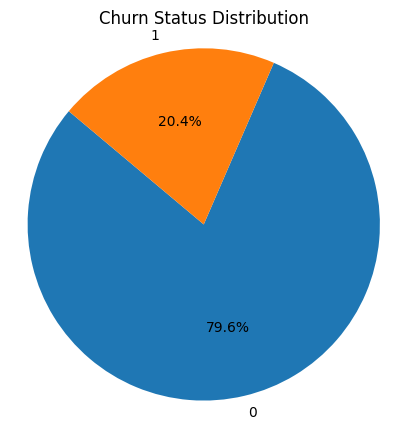

In [6]:
# Among all recorded customers, how many of them are churned?
# Pie chart for ChurnStatus
plt.figure(figsize=(5, 5))
plt.pie(data['ChurnStatus'].value_counts(), labels=data['ChurnStatus'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.title('Churn Status Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

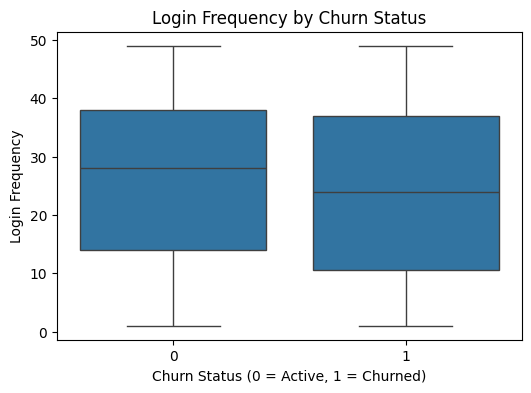

In [ ]:
# Box plot for LoginFrequency for both churned and non-churned customers
plt.figure(figsize=(6, 4))
sns.boxplot(x='ChurnStatus', y='LoginFrequency', data=data)
plt.title('Login Frequency by Churn Status')
plt.xlabel('Churn Status (0 = Active, 1 = Churned)')
plt.ylabel('Login Frequency')
plt.show()

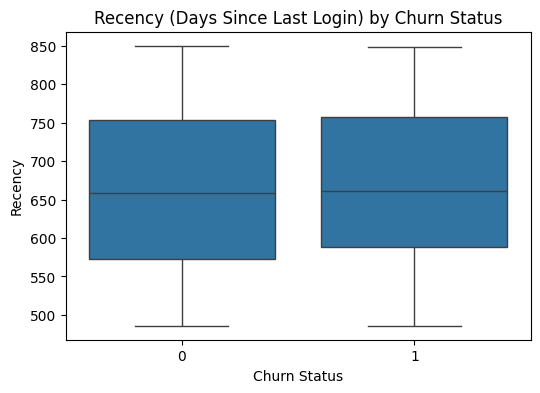

In [ ]:
# Box plot for Recency (days since last login) for both churned and non-churned customers
from datetime import datetime

# Convert to datetime
data['LastLoginDate'] = pd.to_datetime(data['LastLoginDate'])

# Calculate recency (days since last login)
data['Recency'] = (datetime.today() - data['LastLoginDate']).dt.days

# Plot
plt.figure(figsize=(6, 4))
sns.boxplot(x='ChurnStatus', y='Recency', data=data)
plt.title('Recency (Days Since Last Login) by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Recency')
plt.show()

In [23]:
# the lower the recency, the more recent the login, and the more likely the customer is active.

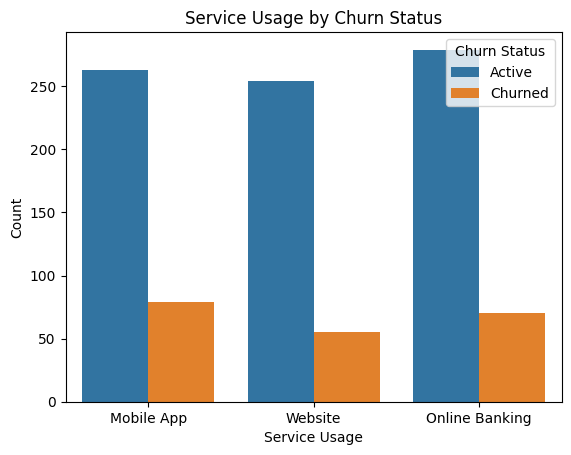

In [16]:
# ServiceUsage VS ChurnStatus
plt
sns.countplot(x='ServiceUsage', hue='ChurnStatus', data=data)
plt.title('Service Usage by Churn Status')
plt.xlabel('Service Usage')
plt.ylabel('Count')
plt.legend(title='Churn Status', loc='upper right', labels=['Active', 'Churned'])
plt.show()

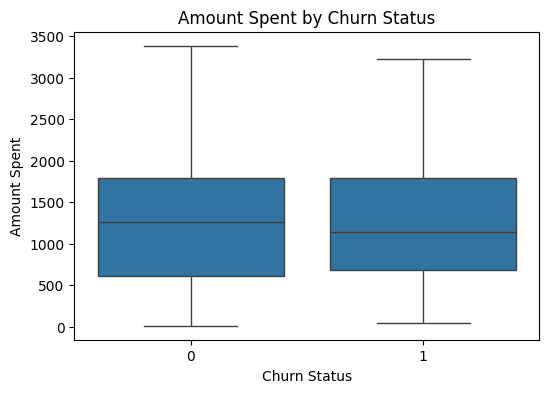

In [17]:
# AmountSpent VS ChurnStatus
plt.figure(figsize=(6, 4))
sns.boxplot(x='ChurnStatus', y='AmountSpent', data=data)
plt.title('Amount Spent by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Amount Spent')
plt.show()

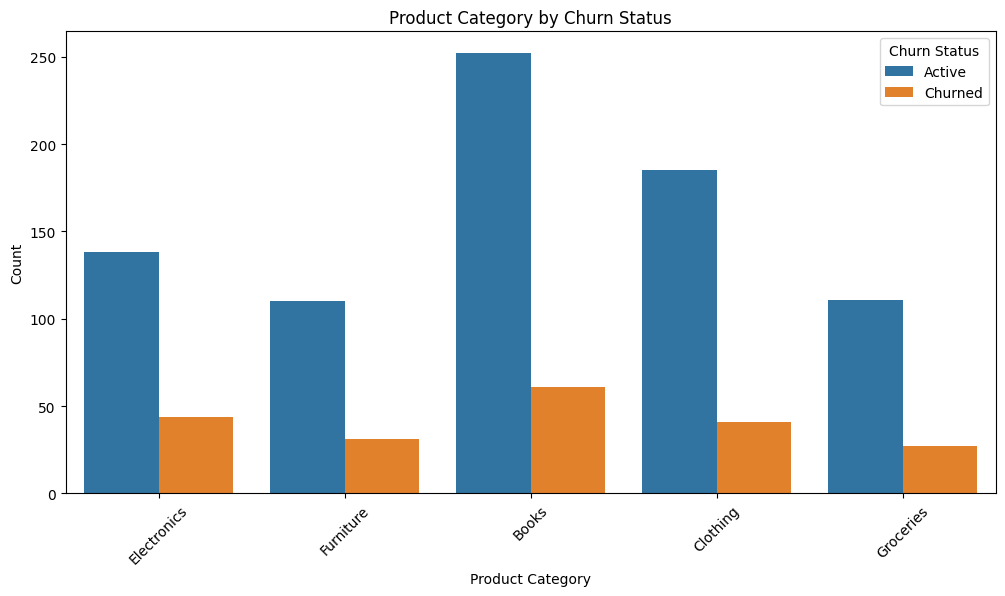

In [18]:
# ProductCategory VS ChurnStatus
plt.figure(figsize=(12, 6))
sns.countplot(x='ProductCategory', hue='ChurnStatus', data=data)
plt.title('Product Category by Churn Status')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.legend(title='Churn Status', loc='upper right', labels=['Active', 'Churned'])
plt.xticks(rotation=45)
plt.show()

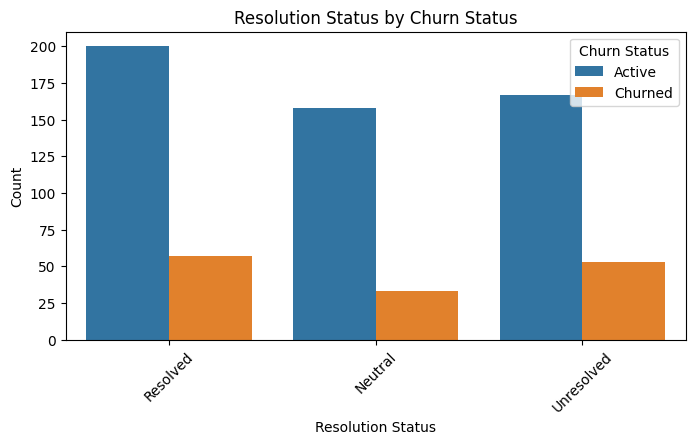

In [19]:
# ResolutionStatus VS ChurnStatus
plt.figure(figsize=(8, 4))
sns.countplot(x='ResolutionStatus', hue='ChurnStatus', data=data)
plt.title('Resolution Status by Churn Status')
plt.xlabel('Resolution Status')
plt.ylabel('Count')
plt.legend(title='Churn Status', loc='upper right', labels=['Active', 'Churned'])
plt.xticks(rotation=45)
plt.show()

Data Cleaning

In [20]:
data.head(10)

,CustomerID,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage,AmountSpent,ProductCategory,ResolutionStatus,Recency
0,1,0,2023-10-21,34,Mobile App,416.50,Electronics,Resolved,557
1,2,1,2023-12-05,5,Website,1547.42,Electronics,Resolved,512
2,3,0,2023-11-15,3,Website,1702.98,Furniture,Resolved,532
3,4,0,2023-08-25,2,Website,917.29,Electronics,Neutral,614
4,5,0,2023-10-27,41,Website,2001.49,Electronics,NaN,551
5,6,0,2023-09-17,2,Website,1164.29,Furniture,Resolved,591
6,7,0,2023-01-07,32,Mobile App,86.73,Books,NaN,844
7,8,1,2023-04-22,17,Online Banking,2046.88,Books,Unresolved,739
8,9,0,2023-06-27,24,Website,1317.24,Clothing,Resolved,673
9,10,1,2023-01-13,29,Online Banking,1397.36,Furniture,NaN,838


In [21]:
# Change null values in ResolutionStatus to 'None'
data['ResolutionStatus'] = data['ResolutionStatus'].fillna('None')
data['ResolutionStatus'].isnull().sum()

np.int64(0)

In [22]:
# Make values in AmountSpent column have 2 decimal places
data['AmountSpent'] = data['AmountSpent'].round(2)
data.head(10)

,CustomerID,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage,AmountSpent,ProductCategory,ResolutionStatus,Recency
0,1,0,2023-10-21,34,Mobile App,416.50,Electronics,Resolved,557
1,2,1,2023-12-05,5,Website,1547.42,Electronics,Resolved,512
2,3,0,2023-11-15,3,Website,1702.98,Furniture,Resolved,532
3,4,0,2023-08-25,2,Website,917.29,Electronics,Neutral,614
4,5,0,2023-10-27,41,Website,2001.49,Electronics,None,551
5,6,0,2023-09-17,2,Website,1164.29,Furniture,Resolved,591
6,7,0,2023-01-07,32,Mobile App,86.73,Books,None,844
7,8,1,2023-04-22,17,Online Banking,2046.88,Books,Unresolved,739
8,9,0,2023-06-27,24,Website,1317.24,Clothing,Resolved,673
9,10,1,2023-01-13,29,Online Banking,1397.36,Furniture,None,838


In [24]:
# Remove 00:00:00 from LastLoginDate column
data['LastLoginDate'] = data['LastLoginDate'].dt.date
data.head(10)

,CustomerID,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage,AmountSpent,ProductCategory,ResolutionStatus,Recency
0,1,0,2023-10-21,34,Mobile App,416.50,Electronics,Resolved,557
1,2,1,2023-12-05,5,Website,1547.42,Electronics,Resolved,512
2,3,0,2023-11-15,3,Website,1702.98,Furniture,Resolved,532
3,4,0,2023-08-25,2,Website,917.29,Electronics,Neutral,614
4,5,0,2023-10-27,41,Website,2001.49,Electronics,None,551
5,6,0,2023-09-17,2,Website,1164.29,Furniture,Resolved,591
6,7,0,2023-01-07,32,Mobile App,86.73,Books,None,844
7,8,1,2023-04-22,17,Online Banking,2046.88,Books,Unresolved,739
8,9,0,2023-06-27,24,Website,1317.24,Clothing,Resolved,673
9,10,1,2023-01-13,29,Online Banking,1397.36,Furniture,None,838


In [25]:
data.to_csv('final_df.csv', index=False)

The resulted dataset will be ready for model building. However, the dataset lack customer records, and it will result in less accurate prediction model. Therefore, to fix this, we should gather more data before building the model. 